In [1]:
import numpy as np
import readgadget
import readfof
import redshift_space_library as RSL
import matplotlib.pyplot as plt

In [2]:
snapdir = '/home/jovyan/Data/Halos/FoF/EQ_p/420' #folder hosting the catalogue
snapnum = 4                                      #number of the catalog (4-->z=0, 3-->z=0.5, 2-->z=1, 1-->z=2, 0-->z=3)

In [3]:
# get the name of the corresponding snapshot
snapshot = '/home/jovyan/Data/Snapshots/EQ_p/420/snapdir_%03d/snap_%03d'%(snapnum,snapnum)

# read the redshift, boxsize, cosmology...etc in the header
header   = readgadget.header(snapshot)
BoxSize  = header.boxsize/1e3  #Mpc/h
Nall     = header.nall         #Total number of particles
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
Omega_l  = header.omega_l      #value of Omega_l
h        = header.hubble       #value of h
redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)

print('BoxSize = %.3f Mpc/h'%BoxSize)
print('Number of particles in the snapshot:',Nall)
print('Omega_m = %.3f'%Omega_m)
print('Omega_l = %.3f'%Omega_l)
print('h = %.3f'%h)
print('redshift = %.1f'%redshift)

BoxSize = 1000.000 Mpc/h
Number of particles in the snapshot: [        0 134217728         0         0         0         0]
Omega_m = 0.318
Omega_l = 0.682
h = 0.671
redshift = 0.0


In [4]:
# read the halo catalogue
FoF = readfof.FoF_catalog(snapdir, snapnum, long_ids=False,
                          swap=False, SFR=False, read_IDs=False)

# get the properties of the halos
pos_h  = FoF.GroupPos/1e3            #Halo positions in Mpc/h
vel_h  = FoF.GroupVel*(1.0+redshift) #Halo peculiar velocities in km/s
mass_h = FoF.GroupMass*1e10          #Halo masses in Msun/h
Np_h   = FoF.GroupLen                #Number of CDM particles in the halo. Even in simulations with massive neutrinos, this will be just the number of CDM particles

(array([1.87149e+05, 1.04817e+05, 5.80270e+04, 3.05140e+04, 1.53360e+04,
        6.73700e+03, 2.53700e+03, 7.46000e+02, 1.38000e+02, 2.20000e+01]),
 array([1.30103   , 1.55224505, 1.8034601 , 2.05467516, 2.30589021,
        2.55710526, 2.80832032, 3.05953537, 3.31075043, 3.56196548,
        3.81318053]),
 <BarContainer object of 10 artists>)

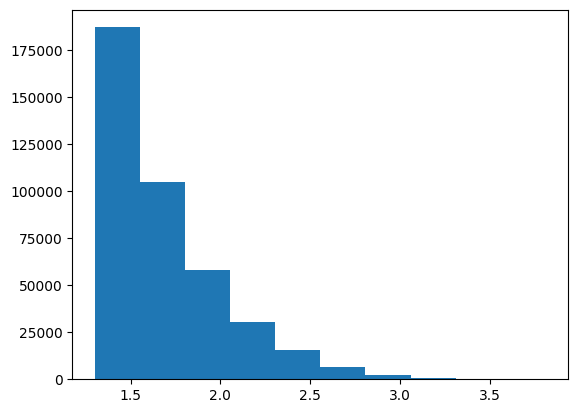

In [57]:
plt.hist(np.log10(Np_h))

In [85]:
ind_clus_fof = np.where( (Np_h > 81) & (np.log10(mass_h) > 13))[0]
len(ind_clus_fof)

84951

In [46]:
len(mass_h)

406023

In [50]:
FoF.TotNgroups

np.int32(406023)

In [6]:
dir(FoF)

['GroupLen',
 'GroupMass',
 'GroupOffset',
 'GroupPos',
 'GroupTLen',
 'GroupTMass',
 'GroupVel',
 'Nfiles',
 'Ngroups',
 'Nids',
 'TotNgroups',
 'TotNids',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__']

In [29]:
!ls /home/jovyan/Data/Halos/Rockstar/EQ_p/420

out_0_pid.list	out_3_pid.list	rockstar.cfg	     rockstar.slurm.log
out_1_pid.list	out_4_pid.list	rockstar_params.cfg
out_2_pid.list	output.dat	rockstar.slurm


In [51]:
import numpy as np

# catalog file
f_catalog = '/home/jovyan/Data/Halos/Rockstar/EQ_p/420/out_4_pid.list'

# read the halo catalog
data = np.loadtxt(f_catalog)

'''
#ID DescID Mvir Vmax Vrms Rvir Rs Np X Y Z VX VY VZ JX JY JZ Spin rs_klypin Mvir_all M200b M200c M500c M2500c Xoff Voff spin_bullock b_to_a c_to_a A[x] A[y] A[z] b_to_a(500c) c_to_a(500c) A[x](500c) A[y](500c) A[z](500c) T/|U| M_pe_Behroozi M_pe_Diemer Halfmass_Radius PID
'''

'\n#ID DescID Mvir Vmax Vrms Rvir Rs Np X Y Z VX VY VZ JX JY JZ Spin rs_klypin Mvir_all M200b M200c M500c M2500c Xoff Voff spin_bullock b_to_a c_to_a A[x] A[y] A[z] b_to_a(500c) c_to_a(500c) A[x](500c) A[y](500c) A[z](500c) T/|U| M_pe_Behroozi M_pe_Diemer Halfmass_Radius PID\n'

In [52]:
data.shape

(87140, 42)

In [77]:
ind_clus_rock = np.where( (data[:,-1] == -1) & (np.log10(data[:,2]) > 13))[0]
len(ind_clus_rock)

84508

Text(0, 0.5, 'Msun/h')

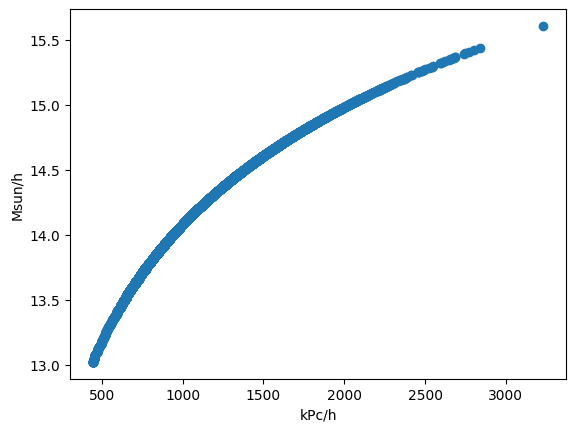

In [78]:
plt.scatter(data[ind_clus_rock,5], np.log10(data[ind_clus_rock,2]))
plt.xlabel('kPc/h')
plt.ylabel('Msun/h')


Text(0.5, 0, 'kPc/h')

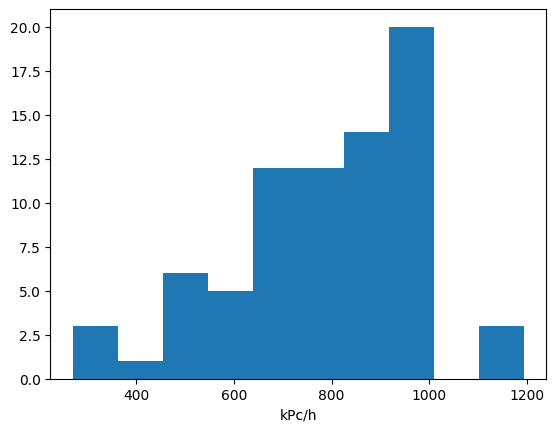

In [38]:
plt.hist(data[:,5])
plt.xlabel('kPc/h')

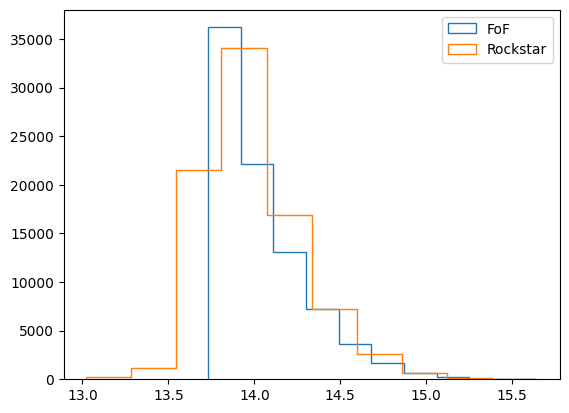

In [87]:
plt.hist(np.log10(mass_h[ind_clus_fof]), histtype = 'step', density = False, label = 'FoF', bins = 10)
plt.hist(np.log10(data[ind_clus_rock,20]), histtype = 'step', density = False, label = 'Rockstar', bins = 10)
plt.legend()

(0.0, 100.0)

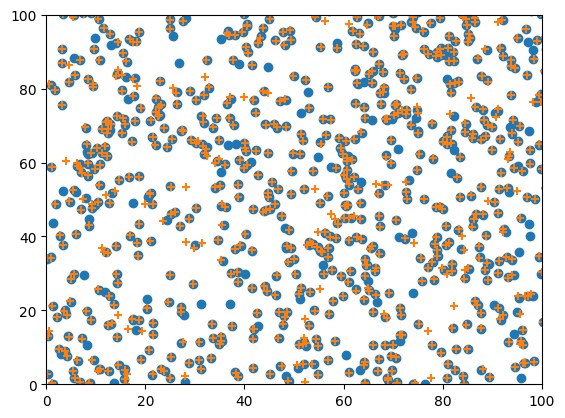

In [89]:
plt.scatter(pos_h[ind_clus_fof,0], pos_h[ind_clus_fof,1])
plt.scatter(data[ind_clus_rock,8], data[ind_clus_rock,9], marker = '+')

plt.xlim(0,100)
plt.ylim(0,100)

In [100]:
data[ind_clus_rock,8:11].shape

(84508, 3)

In [102]:
from scipy.spatial import cKDTree

In [111]:
tree = cKDTree(data[ind_clus_rock,8:11])

# distancia máxima para considerar match
tol = 1e-1

dist, idx = tree.query(pos_h[ind_clus_fof,0:3], distance_upper_bound=tol)

# filtrar matches válidos
mask = dist < tol

(0.0, 100.0)

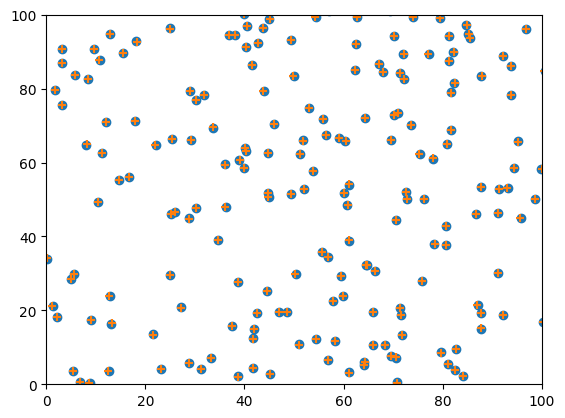

In [113]:
plt.scatter(pos_h[ind_clus_fof[mask],0], pos_h[ind_clus_fof[mask],1])
plt.scatter(data[ind_clus_rock[idx[mask]],8], data[ind_clus_rock[idx[mask]],9], marker = '+')

plt.xlim(0,100)
plt.ylim(0,100)

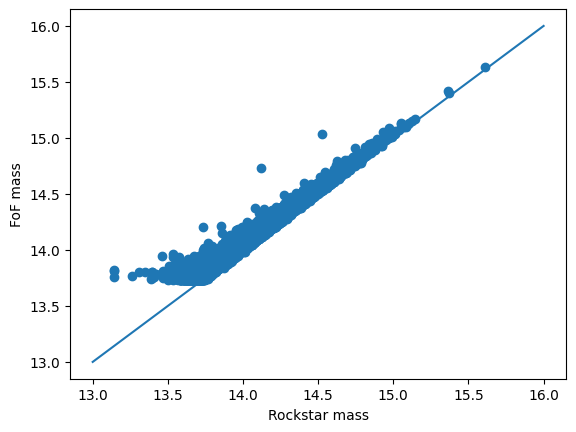

In [118]:
plt.scatter(np.log10(data[ind_clus_rock[idx[mask]],2]), np.log10(mass_h[ind_clus_fof[mask]]))
plt.plot([13,16], [13,16])

plt.xlabel('Rockstar mass')
plt.ylabel('FoF mass')

plt.savefig('mass_comparison.pdf')

# CAMELS

In [46]:
import numpy as np
import readgadget
import readfof
import redshift_space_library as RSL
import matplotlib.pyplot as plt
import h5py
from scipy.spatial import cKDTree

In [96]:
!ls /home/jovyan/Data/FOF_Subfind/IllustrisTNG_DM/CV/CV_11

groups_014.hdf5  groups_044.hdf5  groups_064.hdf5  groups_084.hdf5
groups_018.hdf5  groups_046.hdf5  groups_066.hdf5  groups_086.hdf5
groups_024.hdf5  groups_048.hdf5  groups_068.hdf5  groups_088.hdf5
groups_028.hdf5  groups_050.hdf5  groups_070.hdf5  groups_090.hdf5
groups_032.hdf5  groups_052.hdf5  groups_072.hdf5  OUTPUT
groups_034.hdf5  groups_054.hdf5  groups_074.hdf5  OUTPUT.err
groups_036.hdf5  groups_056.hdf5  groups_076.hdf5  parameters-usedvalues
groups_038.hdf5  groups_058.hdf5  groups_078.hdf5
groups_040.hdf5  groups_060.hdf5  groups_080.hdf5
groups_042.hdf5  groups_062.hdf5  groups_082.hdf5


In [97]:
f_catalog  = '/home/jovyan/Data/FOF_Subfind/IllustrisTNG/L25n256/CV/CV_11/groups_090.hdf5'
f_catalog_dm  = '/home/jovyan/Data/FOF_Subfind/IllustrisTNG_DM/L25n256/CV/CV_11/groups_090.hdf5'

In [98]:
f = h5py.File(f_catalog, 'r')
print(f.keys())
print(f['IDs'].keys())

<KeysViewHDF5 ['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']>
<KeysViewHDF5 []>


In [99]:
f['Group'].keys()

<KeysViewHDF5 ['GroupBHMass', 'GroupBHMdot', 'GroupCM', 'GroupFirstSub', 'GroupGasMetalFractions', 'GroupGasMetallicity', 'GroupLen', 'GroupLenType', 'GroupMass', 'GroupMassType', 'GroupNsubs', 'GroupPos', 'GroupSFR', 'GroupStarMetalFractions', 'GroupStarMetallicity', 'GroupVel', 'GroupWindMass', 'Group_M_Crit200', 'Group_M_Crit500', 'Group_M_Mean200', 'Group_M_TopHat200', 'Group_R_Crit200', 'Group_R_Crit500', 'Group_R_Mean200', 'Group_R_TopHat200']>

In [100]:
f = h5py.File(f_catalog, 'r')

fof_pos = f['Group/GroupPos'][()] / 1e3
fof_mass = f['Group/GroupMass'][()] * 1e10

ind = np.where(np.log10(fof_mass) > 13)[0]

fof_pos = fof_pos[ind]
fof_mass = fof_mass[ind]

In [102]:
f_dm = h5py.File(f_catalog_dm, 'r')

fof_dm_pos = f['Group/GroupPos'][()] / 1e3
fof_dm_mass = f['Group/GroupMass'][()] * 1e10

ind_dm = np.where(np.log10(fof_mass) > 13)[0]

fof_dm_pos = fof_dm_pos[ind_dm]
fof_dm_mass = fof_dm_mass[ind_dm]

In [103]:
!ls /home/jovyan/Data/Rockstar/IllustrisTNG_DM/L25n256/CV/CV_11/hlists


hlist_0.14286.list  hlist_0.31750.list	hlist_0.48819.list  hlist_0.75065.list
hlist_0.16667.list  hlist_0.33305.list	hlist_0.51209.list  hlist_0.78740.list
hlist_0.20000.list  hlist_0.34935.list	hlist_0.53717.list  hlist_0.82596.list
hlist_0.22222.list  hlist_0.36646.list	hlist_0.56347.list  hlist_0.86640.list
hlist_0.25000.list  hlist_0.38440.list	hlist_0.59106.list  hlist_0.90882.list
hlist_0.26224.list  hlist_0.40322.list	hlist_0.62000.list  hlist_0.95332.list
hlist_0.27508.list  hlist_0.42297.list	hlist_0.65036.list  hlist_1.00000.list
hlist_0.28855.list  hlist_0.44368.list	hlist_0.68220.list
hlist_0.30268.list  hlist_0.46540.list	hlist_0.71561.list


In [104]:
# catalog file
f_catalog = '/home/jovyan/Data/Rockstar/IllustrisTNG/L25n256/CV/CV_11/hlists/hlist_1.00000.list'

# read the halo catalog
data = np.loadtxt(f_catalog)

f_catalog_dm = '/home/jovyan/Data/Rockstar/IllustrisTNG_DM/L25n256/CV/CV_11/hlists/hlist_1.00000.list'

# read the halo catalog
data_dm = np.loadtxt(f_catalog_dm)
'''
#scale(0) id(1) desc_scale(2) desc_id(3) num_prog(4) pid(5) upid(6) desc_pid(7) phantom(8) sam_Mvir(9) Mvir(10)
Rvir(11) rs(12) vrms(13) mmp?(14) scale_of_last_MM(15) vmax(16) x(17) y(18) z(19) vx(20) vy(21) vz(22)
Jx(23) Jy(24) Jz(25) Spin(26) Breadth_first_ID(27) Depth_first_ID(28) Tree_root_ID(29) Orig_halo_ID(30)
Snap_idx(31) Next_coprogenitor_depthfirst_ID(32) Last_progenitor_depthfirst_ID(33) Last_mainleaf_depthfirst_ID(34) 
Tidal_Force(35) Tidal_ID(36) Rs_Klypin(37) Mvir_all(38) M200b(39) M200c(40) M500c(41) M2500c(42) Xoff(43) Voff(44)
Spin_Bullock(45) b_to_a(46) c_to_a(47) A[x](48) A[y](49) A[z](50) b_to_a(500c)(51) c_to_a(500c)(52) A[x](500c)(53)
A[y](500c)(54) A[z](500c)(55) T/|U|(56) M_pe_Behroozi(57) M_pe_Diemer(58) Type(59) SM(60) Gas(61) BH_Mass(62) Macc(63)
Mpeak(64) Vacc(65) Vpeak(66) Halfmass_Scale(67) Acc_Rate_Inst(68) Acc_Rate_100Myr(69) Acc_Rate_1*Tdyn(70) Acc_Rate_2*Tdyn(71)
Acc_Rate_Mpeak(72) Acc_Log_Vmax_Inst(73) Acc_Log_Vmax_1*Tdyn(74) Mpeak_Scale(75) Acc_Scale(76) First_Acc_Scale(77) 
First_Acc_Mvir(78) First_Acc_Vmax(79) Vmax\@Mpeak(80) Tidal_Force_Tdyn(81) Log_(Vmax/Vmax_max(Tdyn;Tmpeak))(82)
Time_to_future_merger(83) Future_merger_MMP_ID(84)'''

'\n#scale(0) id(1) desc_scale(2) desc_id(3) num_prog(4) pid(5) upid(6) desc_pid(7) phantom(8) sam_Mvir(9) Mvir(10)\nRvir(11) rs(12) vrms(13) mmp?(14) scale_of_last_MM(15) vmax(16) x(17) y(18) z(19) vx(20) vy(21) vz(22)\nJx(23) Jy(24) Jz(25) Spin(26) Breadth_first_ID(27) Depth_first_ID(28) Tree_root_ID(29) Orig_halo_ID(30)\nSnap_idx(31) Next_coprogenitor_depthfirst_ID(32) Last_progenitor_depthfirst_ID(33) Last_mainleaf_depthfirst_ID(34) \nTidal_Force(35) Tidal_ID(36) Rs_Klypin(37) Mvir_all(38) M200b(39) M200c(40) M500c(41) M2500c(42) Xoff(43) Voff(44)\nSpin_Bullock(45) b_to_a(46) c_to_a(47) A[x](48) A[y](49) A[z](50) b_to_a(500c)(51) c_to_a(500c)(52) A[x](500c)(53)\nA[y](500c)(54) A[z](500c)(55) T/|U|(56) M_pe_Behroozi(57) M_pe_Diemer(58) Type(59) SM(60) Gas(61) BH_Mass(62) Macc(63)\nMpeak(64) Vacc(65) Vpeak(66) Halfmass_Scale(67) Acc_Rate_Inst(68) Acc_Rate_100Myr(69) Acc_Rate_1*Tdyn(70) Acc_Rate_2*Tdyn(71)\nAcc_Rate_Mpeak(72) Acc_Log_Vmax_Inst(73) Acc_Log_Vmax_1*Tdyn(74) Mpeak_Scale(75

In [105]:
data = data[np.where(data[:,5] == -1)[0]]
data_dm = data_dm[np.where(data_dm[:,5] == -1)[0]]

In [49]:
data[:,17:19].shape

(6774, 2)

In [112]:
tree = cKDTree(data[:,17:20])

# distancia máxima para considerar match
tol = 1e-1

dist, idx = tree.query(fof_pos, distance_upper_bound=tol)

# filtrar matches válidos
mask_fof = dist < tol

dist_dm, idx_dm = tree.query(fof_dm_pos, distance_upper_bound=tol)

# filtrar matches válidos
mask_fof_dm = dist_dm < tol

In [113]:
tree = cKDTree(fof_pos)

# distancia máxima para considerar match
tol = 1e-1

dist, idx = tree.query(data[:,17:20], distance_upper_bound=tol)

# filtrar matches válidos
mask_rock = dist < tol

dist_dm, idx_dm = tree.query(data_dm[:,17:20], distance_upper_bound=tol)

# filtrar matches válidos
mask_rock_dm = dist_dm < tol

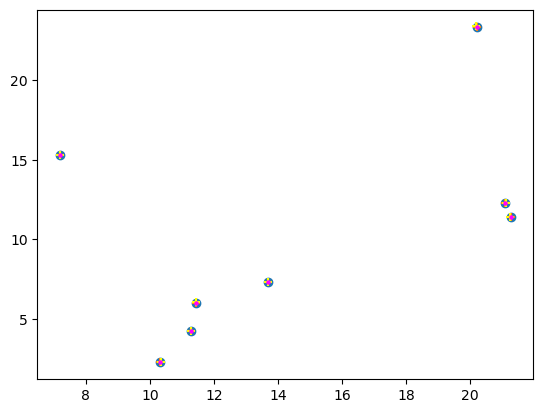

In [116]:
plt.scatter(fof_pos[mask_fof,0], fof_pos[mask_fof,1])
plt.scatter(data[mask_rock,17], data[mask_rock,18], marker = '+')
plt.scatter(data_dm[mask_rock_dm,17], data_dm[mask_rock_dm,18], marker = '+', color = 'yellow')
plt.scatter(fof_dm_pos[mask_fof_dm,0], fof_dm_pos[mask_fof_dm,1], s = 5, color = 'magenta')

#plt.xlim(0,5)
#plt.ylim(0,5)

Text(0, 0.5, 'FoF DM-only mass')

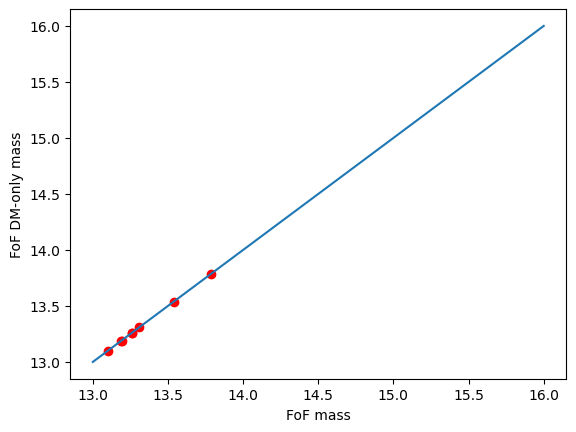

In [132]:
plt.scatter(np.log10(fof_mass[mask_fof]), np.log10(fof_dm_mass[mask_fof_dm]), color = 'red')
plt.plot([13,16],[13,16])


plt.xlabel('FoF mass')
plt.ylabel('FoF DM-only mass')

Text(0, 0.5, 'FoF mass')

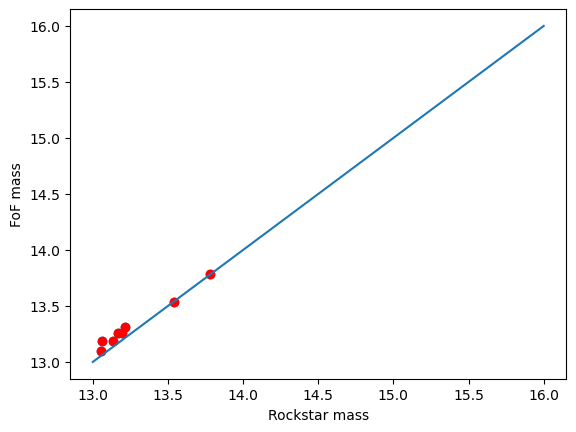

In [118]:
plt.scatter(np.log10(data[mask_rock,10]), np.log10(fof_mass[mask_fof]))
plt.plot([13,16],[13,16])


plt.xlabel('Rockstar mass')
plt.ylabel('FoF mass')

Text(0, 0.5, 'Rockstar DM-only mass')

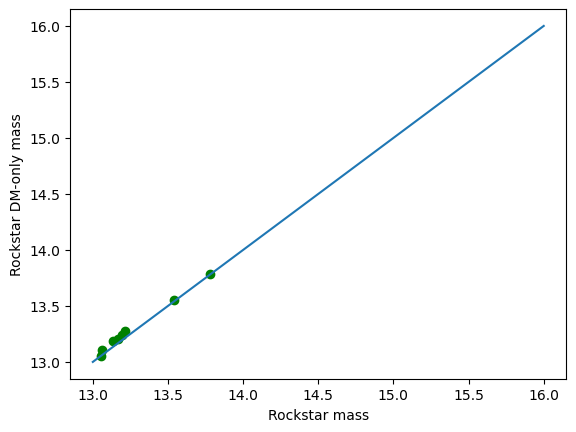

In [131]:
plt.scatter(np.log10(data[mask_rock,10]), np.log10(data_dm[mask_rock_dm,10]), color = 'green')
plt.plot([13,16],[13,16])


plt.xlabel('Rockstar mass')
plt.ylabel('Rockstar DM-only mass')